# Tugas Pertemuan 3

## BUSSINES UNDERSTANDING

### Latar Belakang dan Tujuan Penelitian
Penelitian ini bertujuan untuk menganalisis dan memodelkan kualitas udara di wilayah Kecamatan Masalembu, Kabupaten Sumenep, Madura. Observasi dilakukan menggunakan data spasio temporal berbasis satelit yang direkam selama rentang waktu satu tahun, terhitung sejak 24 Agustus 2025 hingga 24 Agustus 2026. Jendela waktu observasi ini menghasilkan 365 titik data harian (baris data) untuk setiap metrik kualitas udara. Tujuan akhir dari studi ini adalah memanfaatkan Time Series Feature Extraction Library (TSFEL) untuk mengekstraksi 68 fitur dari data deret waktu polutan, guna mengidentifikasi pola, karakteristik, dan anomali kualitas udara secara komprehensif.

### Ruang Lingkup dan Skenario Pengolahan Data
Proses pengumpulan data awal melibatkan ekstraksi lima parameter gas polutan, yaitu CO, NO2, O3, SO2, dan CH4. Pada fase Data Understanding dan prapemrosesan, seluruh variabel dari kelima polutan tersebut akan dievaluasi, ditransformasi, dan dibersihkan guna memastikan integritas serta validitas dataset secara keseluruhan.

Meskipun pembersihan data dilakukan pada seluruh parameter, batasan masalah pada penelitian ini menetapkan bahwa tahapan analisis lanjutan termasuk ekstraksi 68 fitur TSFEL dan pemodelan akhir hanya akan difokuskan pada variabel Karbon Monoksida (CO). Keempat polutan lainnya dipertahankan pada tahap awal sebagai pemenuhan spesifikasi penugasan sebelumnya dan untuk memberikan konteks kondisi atmosfer secara umum.

### Deskripsi Parameter Polutan
Variabel polutan yang tercakup dalam dataset observasi wilayah Masalembu meliputi:

- CO (Karbon Monoksida): Merupakan variabel target utama untuk ekstraksi fitur TSFEL. Gas ini umumnya mengindikasikan tingkat emisi dari pembakaran tidak sempurna dan aktivitas antropogenik.

- NO2 (Nitrogen Dioksida): Polutan primer yang bersumber dari aktivitas emisi bahan bakar, digunakan sebagai indikator tambahan tingkat polusi udara ambien.

- O3 (Ozon Permukaan): Polutan sekunder hasil reaksi fotokimia di atmosfer yang dipengaruhi oleh intensitas radiasi matahari dan gas prekursor di wilayah observasi.

- SO2 (Sulfur Dioksida): Parameter yang mengindikasikan keberadaan emisi berbasis sulfur, baik dari aktivitas pelayaran laut maupun sumber eksternal lainnya.

- CH4 (Metana): Emisi gas rumah kaca yang relevan untuk diamati pada wilayah kepulauan, sering kali berkaitan dengan proses dekomposisi organik alami maupun aktivitas domestik.

## DATA UNDERSTANDING

Pada tahap ini, kita akan mulai mengumpulkan data, mulai dari menarik data, kemudian kita akan mengupas data data tersebut, sehingga kita dapat memahami secara utuh data apa yang sedang kita gunakan saat ini.

### Mengumpulkan data

Kita akan menghubungkan copernicus dengan koordinat masalembu yang sudah kita ambil dari geojson.


In [9]:
import folium

# 1. Definisikan AOI (GeoJSON) Anda
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [114.3944446, -5.5423607], [114.3939531, -5.5642533],
            [114.3950039, -5.5688155], [114.3988683, -5.5712245],
            [114.4149544, -5.5740227], [114.4222159, -5.5893249],
            [114.4349065, -5.5873077], [114.4477753, -5.5785626],
            [114.45452, -5.5647903],   [114.4512776, -5.5581054],
            [114.4525677, -5.547253],   [114.4431058, -5.5478645],
            [114.4401566, -5.5490876],  [114.4390507, -5.5448068],
            [114.4224617, -5.5461522],  [114.4138599, -5.5449292],
            [114.4129997, -5.5419938],  [114.4153345, -5.5364899],
            [114.4125082, -5.5322091],  [114.4123853, -5.5322091],
            [114.3944446, -5.5423607]
          ]
        ]
      }
    }
  ]
}

# 2. Titik tengah fokus peta
center_lat = -5.56
center_lon = 114.42

# 3. Buat peta dasar dengan FITUR INTERAKTIF YANG DIMATIKAN
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=13, 
    tiles="OpenStreetMap",
    zoom_control=False,          # Menghilangkan tombol [+] dan [-]
    scrollWheelZoom=False,       # Mematikan zoom pakai scroll mouse
    doubleClickZoom=False,       # Mematikan zoom pakai klik dua kali
    dragging=False,              # KUNCI UTAMA: Mematikan fitur geser (drag/pan)
    boxZoom=False,               # Mematikan fitur zoom kotak penyaring
    keyboard=False               # Mematikan navigasi via keyboard panah
)

# 4. Tambahkan poligon AOI Anda ke peta
folium.GeoJson(
    aoi,
    name="Statis AOI Layer",
    style_function=lambda feature: {
        "fillColor": "#ff4d4d",   
        "color": "#cc0000",       
        "weight": 3,              
        "fillOpacity": 0.4,       
    }
).add_to(m)

# 5. Simpan peta untuk Jupyter Book dan GitHub Pages
m.save("peta_statis_aoi.html")

# Tampilkan langsung di Jupyter Notebook
m


In [1]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [2]:
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              114.3944446,
              -5.5423607
            ],
            [
              114.3939531,
              -5.5642533
            ],
            [
              114.3950039,
              -5.5688155
            ],
            [
              114.3988683,
              -5.5712245
            ],
            [
              114.4149544,
              -5.5740227
            ],
            [
              114.4222159,
              -5.5893249
            ],
            [
              114.4349065,
              -5.5873077
            ],
            [
              114.4477753,
              -5.5785626
            ],
            [
              114.45452,
              -5.5647903
            ],
            [
              114.4512776,
              -5.5581054
            ],
            [
              114.4525677,
              -5.547253
            ],
            [
              114.4431058,
              -5.5478645
            ],
            [
              114.4401566,
              -5.5490876
            ],
            [
              114.4390507,
              -5.5448068
            ],
            [
              114.4224617,
              -5.5461522
            ],
            [
              114.4138599,
              -5.5449292
            ],
            [
              114.4129997,
              -5.5419938
            ],
            [
              114.4153345,
              -5.5364899
            ],
            [
              114.4125082,
              -5.5322091
            ],
            [
              114.4123853,
              -5.5322091
            ],
            [
              114.3944446,
              -5.5423607
            ]
          ]
        ]
      }
    }
  ]
}

In [9]:
pollutants = ["CO", "NO2", "O3", "SO2", "CH4"]
datacubes = {}

for pol in pollutants:
    datacubes[pol] = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2025-08-24", "2026-08-24"],
        spatial_extent={"west": 114.3939531, "south": -5.5893249, "east": 114.45452, "north": -5.5322091},
        bands=[pol],
    )

In [10]:
# Now aggregate by day to avoid having multiple data per day
# let's create a spatial aggregation to generate mean timeseries data

for pol in pollutants:
    datacubes[pol] = datacubes[pol].aggregate_temporal_period(reducer="mean", period="day")
    datacubes[pol] = datacubes[pol].aggregate_spatial(reducer="mean", geometries=aoi)

In [11]:
jobs = {}

for pol in pollutants:
    jobs[pol] = datacubes[pol].execute_batch(title=f"{pol} Masalembu", outputfile=f"{pol}_Masalembu.nc")

0:00:00 Job 'j-2609131625254a7198c85d7b9b1150c2': send 'start'
0:00:02 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:08 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:14 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:22 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:33 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:00:45 Job 'j-2609131625254a7198c85d7b9b1150c2': queued (progress 0%)
0:01:01 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:01:21 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:01:46 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:02:16 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:02:53 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:03:40 Job 'j-2609131625254a7198c85d7b9b1150c2': running (progress N/A)
0:04:39 Job 'j-2609131625254a7198c85d7b9b1150c2': finished (progress 100%

### Membuat Grafik

Setelah data berhasil diambil, sesuai dengan contoh dari github, kita harus membuat grafik untuk kelimat data polutan tersebut.

In [17]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

pollutants = ["CO", "NO2", "O3", "SO2", "CH4"]
datasets = []

# Membaca kelima file .nc dan menyimpannya ke dalam list
for pol in pollutants:
    ds = xr.load_dataset(f"{pol}_Masalembu.nc")
    datasets.append(ds)

# Menggabungkan kelima data menjadi satu kesatuan berdasarkan waktu
merged_data = xr.merge(datasets)

df_masalembu = merged_data.to_dataframe().reset_index()
df_masalembu['t'] = pd.to_datetime(df_masalembu['t'])

df_masalembu = df_masalembu.set_index('t')

full_time_index = pd.date_range(start="2025-08-24", end="2026-08-23", freq="D")

# Sesuaikan data kita ke indeks waktu yang utuh tersebut
df_masalembu = df_masalembu.reindex(full_time_index)

# Kembalikan kolom waktu menjadi kolom biasa dan ubah namanya menjadi 't'
df_masalembu = df_masalembu.reset_index().rename(columns={'index': 't'})
df_masalembu.to_csv("Data_Masalembu_2526.csv", index=False, sep=";")

print(f"Total baris setelah diperbaiki: {len(df_masalembu)}")

Total baris setelah diperbaiki: 365


In [18]:
# Menghitung rata-rata bergerak per 30 hari untuk menghaluskan fluktuasi harian
merged_data = merged_data.rolling(t=30).mean()

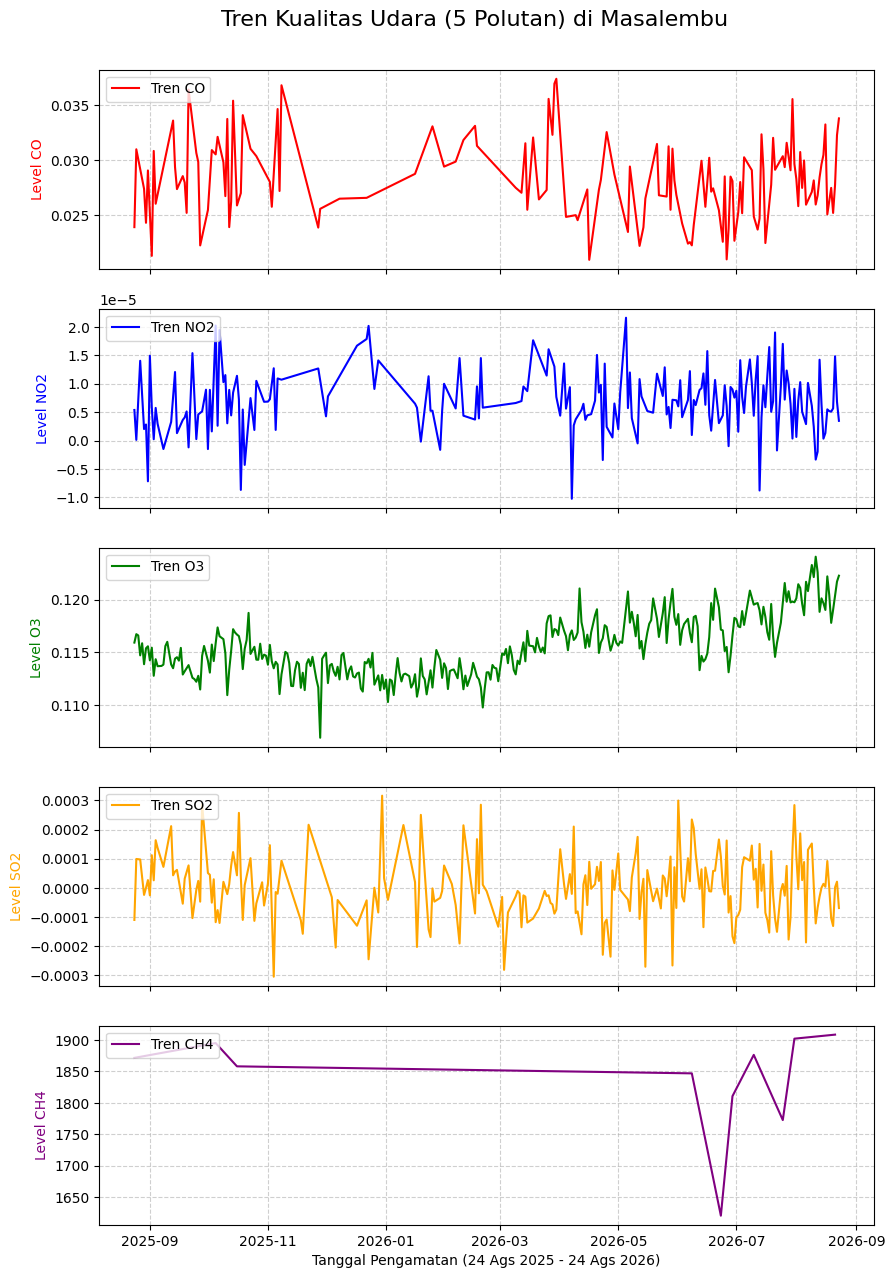

In [21]:
import matplotlib.pyplot as plt

unsur_polutan = ["CO", "NO2", "O3", "SO2", "CH4"]
warna_grafik = ["red", "blue", "green", "orange", "purple"]

# Membuat layout 5 baris grafik
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)

for i, (polutan, warna) in enumerate(zip(unsur_polutan, warna_grafik)):
    # Hanya mengambil hari di mana data polutan tersebut valid (tidak NaN)
    # Ini akan membuat Matplotlib otomatis menyambungkan garis antar titik
    data_udara = df_masalembu[['t', polutan]].dropna()
    
    axes[i].plot(data_udara['t'], data_udara[polutan], color=warna, label=f"Tren {polutan}")
    axes[i].set_ylabel(f"Level {polutan}", color=warna)
    axes[i].legend(loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Tanggal Pengamatan (24 Ags 2025 - 24 Ags 2026)")
plt.suptitle("Tren Kualitas Udara (5 Polutan) di Masalembu", fontsize=16, y=0.92)

# Ekspor grafik menjadi gambar agar bisa dimasukkan ke laporan
plt.savefig("grafik_5_polutan.png", bbox_inches="tight")
plt.show()

### Memeriksa Data Polutan CO
Setelah data polutan dari koordinat yang kita miliki dengan rentang waktu yang telah kita tentukan di tarik, sekarang waktunya kita memeriksa data dari polutan CO

*Langkah PERTAMA*
Memeriksa jumlah baris dari Polutan CO dan dari rentang berapa sampai berapa diambil

In [24]:
# 1. Mengambil hanya kolom Waktu ('t') dan Polutan 'CO'
data_co = df_masalembu[['t', 'CO']]

# 2. Menghitung total keseluruhan baris (tanpa menghapus NaN)
total_baris_keseluruhan = len(data_co)

# 3. Mengidentifikasi rentang waktu awal dan akhir
tanggal_awal = data_co['t'].min().strftime('%d %B %Y')
tanggal_akhir = data_co['t'].max().strftime('%d %B %Y')

print("--- INFO KESELURUHAN DATA CO ---")
print(f"Total Baris Keseluruhan: {total_baris_keseluruhan} baris")
print(f"Rentang Waktu: {tanggal_awal} s/d {tanggal_akhir}")

# Tampilkan 5 baris pertama
print("\n Contoh 5 Baris pertama")
data_co.head()

--- INFO KESELURUHAN DATA CO ---
Total Baris Keseluruhan: 365 baris
Rentang Waktu: 24 August 2025 s/d 23 August 2026

 Contoh 5 Baris pertama


,t,CO
0,2025-08-24,0.023889
1,2025-08-25,0.030957
2,2025-08-26,NaN
3,2025-08-27,NaN
4,2025-08-28,NaN


*Langkah KEDUA*
Kita akan mengecek missing values dan Outliernya

In [26]:

total_baris = len(data_co)
missing_co = data_co['CO'].isna().sum()
persentase_missing = (missing_co / total_baris) * 100

print("=== LAPORAN MISSING VALUES CO ===")
print(f"Total Baris Data : {total_baris}")
print(f"Jumlah Missing   : {missing_co}")
print(f"Persentase       : {persentase_missing:.2f}%")
print("=================================\n")



=== LAPORAN MISSING VALUES CO ===
Total Baris Data : 365
Jumlah Missing   : 225
Persentase       : 61.64%



## DATA PREPARATION

#### MENGATASI MISSING VALUE
Berdasarkan pengecekan sebelumnya, data gas Karbon Monoksida (CO) memiliki tingkat kekosongan (missing values) yang cukup tinggi, yaitu sebesar 61.64% (225 hari dari total 365 hari observasi). Kekosongan ini merupakan hal yang wajar dalam penginderaan jauh (remote sensing) satelit Sentinel-5P, terutama di wilayah kepulauan maritim seperti Masalembu, di mana pantulan permukaan laut yang rendah dan tingginya intensitas tutupan awan sering kali menghalangi sensor satelit untuk menangkap data dengan valid.

Karena metode ekstraksi fitur menggunakan pustaka TSFEL (Time Series Feature Extraction Library) mewajibkan deret waktu yang utuh 100% tanpa ada nilai kosong (NaN), kita perlu melakukan pengisian data atau imputation.

Pada tahap ini, kita menggunakan metode kombinasi:

Linear Interpolation (Interpolasi Linier): Metode utama yang digunakan untuk menambal data kosong di tengah deret waktu. Algoritma ini akan memperkirakan nilai yang hilang dengan cara menarik garis lurus matematis secara proporsional di antara dua titik data valid yang mengapitnya. Hal ini menjaga agar tren kenaikan atau penurunan gas CO tetap terlihat logis dan natural.

Forward Fill (ffill) & Backward Fill (bfill): Digunakan sebagai metode pendukung untuk menambal nilai kosong yang berada di ujung paling awal atau paling akhir dari rentang waktu, di mana interpolasi linier tidak bisa bekerja karena tidak ada titik batas (boundary point).

Berikut adalah implementasi kode untuk melakukan imputation tersebut beserta visualisasi perbandingan data sebelum dan sesudahnya:

Jumlah Missing CO setelah imputasi: 0


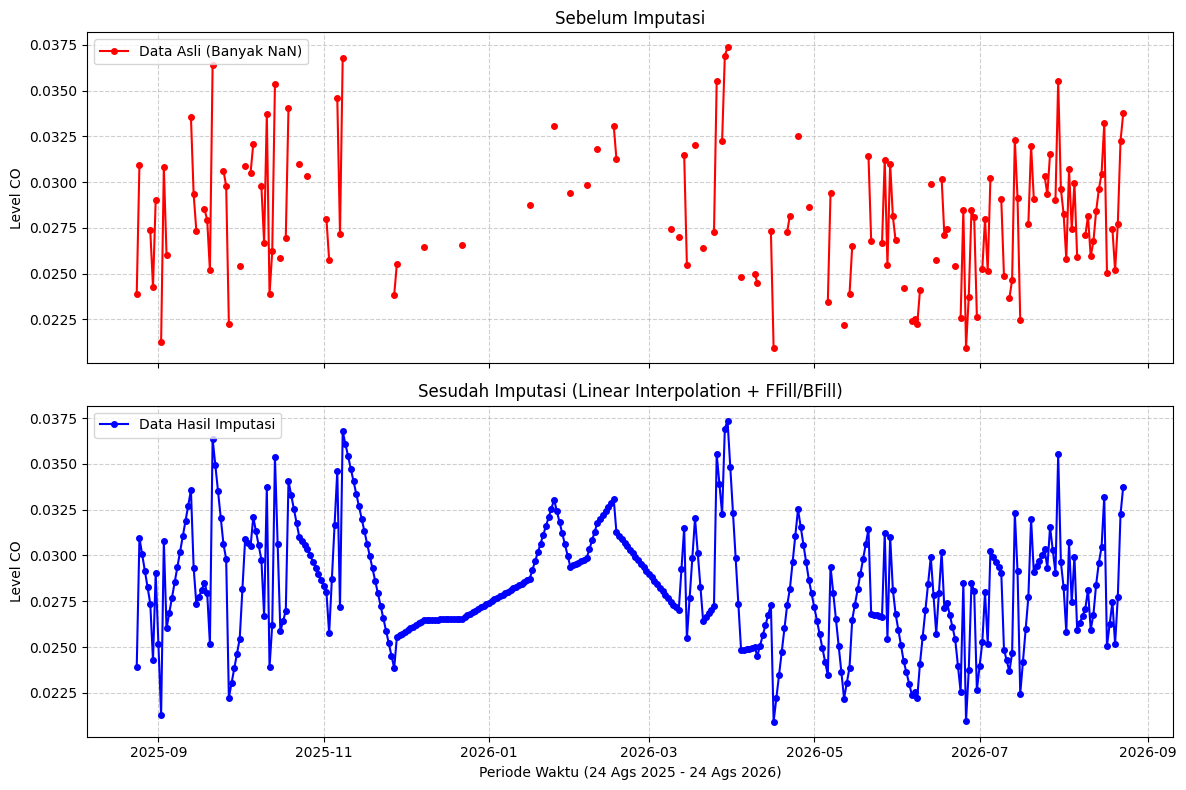

In [28]:
import matplotlib.pyplot as plt

# 1. Salin data agar data mentah tidak tertimpa
data_co_imputed = data_co.copy()

# 2. Proses Imputasi Utama: Linear Interpolation 
# Menarik garis lurus matematis untuk mengisi NaN di antara dua titik data yang ada
data_co_imputed['CO'] = data_co_imputed['CO'].interpolate(method='linear')

# 3. Proses Imputasi Tepi: Forward Fill & Backward Fill
# Menambal sisa NaN di ujung awal atau akhir tanggal yang tidak bisa dijangkau interpolasi
data_co_imputed['CO'] = data_co_imputed['CO'].ffill().bfill()

# Cek hasil akhir
missing_setelah = data_co_imputed['CO'].isna().sum()
print(f"Jumlah Missing CO setelah imputasi: {missing_setelah}")

# 4. Visualisasi Perbandingan
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), dpi=100, sharex=True)

# Grafik Atas: Sebelum Imputasi (Terputus-putus)
axes[0].plot(data_co['t'], data_co['CO'], color='red', marker='o', markersize=4, label='Data Asli (Banyak NaN)')
axes[0].set_title('Sebelum Imputasi', fontsize=12)
axes[0].set_ylabel('Level CO')
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik Bawah: Sesudah Imputasi (Tersambung penuh)
axes[1].plot(data_co_imputed['t'], data_co_imputed['CO'], color='blue', marker='o', markersize=4, label='Data Hasil Imputasi')
axes[1].set_title('Sesudah Imputasi (Linear Interpolation + FFill/BFill)', fontsize=12)
axes[1].set_ylabel('Level CO')
axes[1].set_xlabel('Periode Waktu (24 Ags 2025 - 24 Ags 2026)')
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
# Menyimpan data CO yang sudah bersih dan terisi penuh ke file CSV
data_co_imputed.to_csv("Data_CO_Masalembu_Imputed.csv", index=False, sep=";")
print("Data berhasil disimpan menjadi 'Data_CO_Masalembu_Imputed.csv'")

# 1. Membaca file CSV hasil imputasi dengan separator ';'
df_loaded = pd.read_csv("Data_CO_Masalembu_Imputed.csv", sep=";")

# Konversi kembali kolom waktu ke datetime (opsional untuk keamanan tipe data)
df_loaded['t'] = pd.to_datetime(df_loaded['t'])

# 2. Pengecekan ulang missing values pada kolom CO
total_baris = len(df_loaded)
missing_co = df_loaded['CO'].isna().sum()
persentase_missing = (missing_co / total_baris) * 100

print("=== VERIFIKASI MISSING VALUES (DARI FILE CSV) ===")
print(f"Total Baris Data : {total_baris}")
print(f"Jumlah Missing   : {missing_co}")
print(f"Persentase       : {persentase_missing:.2f}%")
print("==================================================")

# Menampilkan 5 baris pertama untuk memastikan format data terbaca dengan benar
df_loaded.head()

Data berhasil disimpan menjadi 'Data_CO_Masalembu_Imputed.csv'
=== VERIFIKASI MISSING VALUES (DARI FILE CSV) ===
Total Baris Data : 365
Jumlah Missing   : 0
Persentase       : 0.00%


,t,CO
0,2025-08-24,0.023889
1,2025-08-25,0.030957
2,2025-08-26,0.030060
3,2025-08-27,0.029163
4,2025-08-28,0.028265


#### IDENTIFIKASI OUTLIER

Pencilan (outlier) mendefinisikan titik data yang menyimpang secara ekstrem dari tren atau distribusi umum di sekitarnya. 

Pada data deret waktu hasil penginderaan jauh (remote sensing), pencilan lazimnya dipicu oleh galat sensor instrumen, anomali reflektansi permukaan atau awan tipis yang lolos filter awal, maupun fluktuasi atmosfer sesaat. Bagi pipeline Time Series Feature Extraction Library (TSFEL), keberadaan pencilan sangat merusak karena metrik statistik dasar (seperti standar deviasi, variansi, energi, nilai maksimum/minimum) bersifat sangat sensitif terhadap nilai ekstrem, sehingga distorsi kecil pun dapat mencemari representasi fitur secara keseluruhan.

Alih-alih menghapus baris observasi yang berisiko merusak struktur kelengkapan temporal 365 hari, strategi penanganan dilakukan dengan teknik masking nilai ekstrem menjadi NaN diikuti rekonstruksi sinyal melalui tahapan prosedural berikut:
- Identifikasi ambang batas anomali menggunakan metode Interquartile Range (IQR) untuk menghitung kuartil pertama ($Q_1$), kuartil ketiga ($Q_3$), batas bawah ($Q_1 - 1.5 \times IQR$), dan batas atas ($Q_3 + 1.5 \times IQR$).
- Konversi nilai data yang berada di luar rentang batas wajar menjadi NaN (masking).
- Pengisian kembali celah data hasil masking menggunakan kombinasi linear interpolation, forward fill (ffill), dan backward fill (bfill) untuk menjaga kontinuitas tren yang valid bagi TSFEL.

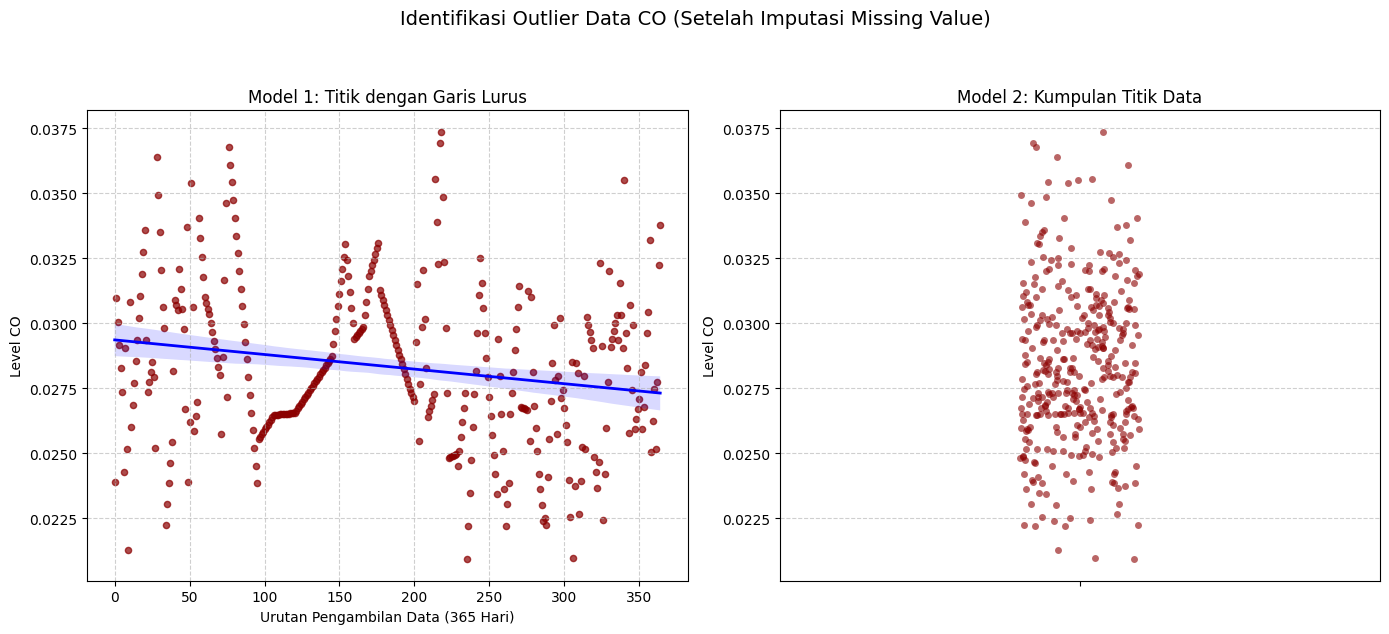

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Membaca data hasil imputasi missing value
df_loaded = pd.read_csv("Data_CO_Masalembu_Imputed.csv", sep=";")
df_loaded['t'] = pd.to_datetime(df_loaded['t'])

# Karena data sudah bersih dari NaN (utuh 365 hari), langsung salin ke variabel analisis
data_co_imputed_clean = df_loaded.copy()

# Membuat kolom urutan numerik (0, 1, 2, ...) sebagai sumbu X untuk garis lurus
data_co_imputed_clean['urutan'] = np.arange(len(data_co_imputed_clean))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), dpi=100)

# Model 1: Titik dengan Garis Lurus (Regresi Linear)
sns.regplot(
    x='urutan', 
    y='CO', 
    data=data_co_imputed_clean, 
    ax=axes[0], 
    scatter_kws={'color': 'darkred', 's': 20, 'alpha': 0.7}, 
    line_kws={'color': 'blue', 'linewidth': 2}
)
axes[0].set_title('Model 1: Titik dengan Garis Lurus', fontsize=12)
axes[0].set_xlabel('Urutan Pengambilan Data (365 Hari)')
axes[0].set_ylabel('Level CO')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Model 2: Kumpulan Titik Murni (Strip Plot)
sns.stripplot(
    y=data_co_imputed_clean['CO'], 
    ax=axes[1], 
    color='darkred', 
    alpha=0.6, 
    jitter=True, 
    size=5
)
axes[1].set_title('Model 2: Kumpulan Titik Data', fontsize=12)
axes[1].set_ylabel('Level CO')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Identifikasi Outlier Data CO (Setelah Imputasi Missing Value)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

#### MEMERIKSA OUTLIER MENGGUNAKAN METODE IQR (Interquartil Range)

In [32]:
# 1. Hitung kuartil dan IQR dari data bersih imputasi
Q1 = data_co_imputed_clean['CO'].quantile(0.25)
Q3 = data_co_imputed_clean['CO'].quantile(0.75)
IQR = Q3 - Q1

# 2. Tentukan ambang batas
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# 3. Identifikasi/filter baris outlier
outlier_mask = (data_co_imputed_clean['CO'] < lower_bound) | (data_co_imputed_clean['CO'] > upper_bound)
df_outliers = data_co_imputed_clean[outlier_mask]

print(f"Batas Bawah : {lower_bound:.6f}")
print(f"Batas Atas  : {upper_bound:.6f}")
print(f"Jumlah Outlier Ditemukan: {len(df_outliers)} baris\n")
print("Daftar Baris Outlier:")
print(df_outliers[['t', 'urutan', 'CO']])

Batas Bawah : 0.020550
Batas Atas  : 0.036196
Jumlah Outlier Ditemukan: 4 baris

Daftar Baris Outlier:
             t  urutan        CO
28  2025-09-21      28  0.036376
76  2025-11-08      76  0.036770
217 2026-03-29     217  0.036915
218 2026-03-30     218  0.037360


#### PENANGANAN OUTLIER MENGGUNAKAN METODE IMPUTATION


Batas Bawah IQR  : 0.020550
Batas Atas IQR   : 0.036196
Jumlah Outlier   : 4 baris

=== TABEL PERBANDINGAN NILAI OUTLIER (SEBELUM VS SESUDAH) ===
         t  sebelum (ekstrem)  sesudah (hasil interpolasi)
2025-09-21           0.036376                     0.030061
2025-11-08           0.036770                     0.031631
2026-03-29           0.036915                     0.033131
2026-03-30           0.037360                     0.033991




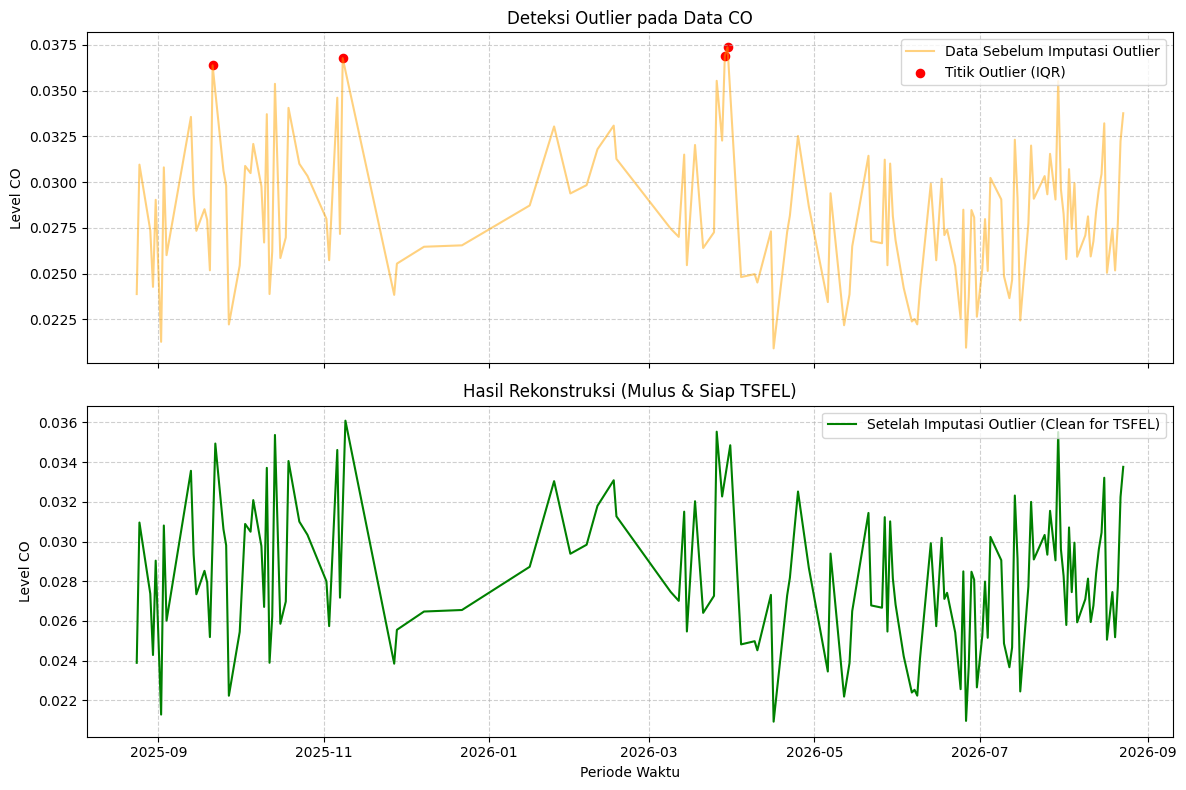

Dataset final tersimpan sebagai 'Data_CO_Masalembu_Ready_TSFEL.csv'


In [34]:
# 1. Memuat data hasil imputasi missing value sebelumnya
df_clean = pd.read_csv("Data_CO_Masalembu_Imputed.csv", sep=";")
df_clean['t'] = pd.to_datetime(df_clean['t'])

# 2. Deteksi outlier menggunakan metode IQR
Q1 = df_clean['CO'].quantile(0.25)
Q3 = df_clean['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df_clean['CO'] < lower_bound) | (df_clean['CO'] > upper_bound)
print(f"Batas Bawah IQR  : {lower_bound:.6f}")
print(f"Batas Atas IQR   : {upper_bound:.6f}")
print(f"Jumlah Outlier   : {outlier_mask.sum()} baris\n")

# 3. Tangkap nilai sebelum eksekusi pada indeks outlier
df_outlier_eval = pd.DataFrame({
    't': df_clean.loc[outlier_mask, 't'],
    'sebelum (ekstrem)': df_clean.loc[outlier_mask, 'CO']
})

# 4. Masking: ubah nilai outlier menjadi NaN
df_masked = df_clean.copy()
df_masked.loc[outlier_mask, 'CO'] = np.nan

# 5. Imputasi ulang area bekas outlier
df_final = df_masked.copy()
df_final['CO'] = df_final['CO'].interpolate(method='linear').ffill().bfill()

# Tangkap nilai sesudah eksekusi pada indeks yang sama
df_outlier_eval['sesudah (hasil interpolasi)'] = df_final.loc[outlier_mask, 'CO']

print("=== TABEL PERBANDINGAN NILAI OUTLIER (SEBELUM VS SESUDAH) ===")
print(df_outlier_eval.to_string(index=False))
print("\n" + "="*50 + "\n")

# 6. Visualisasi perbandingan
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), dpi=100, sharex=True)

# Grafik Atas: Sebelum penanganan outlier (dengan penanda titik merah)
axes[0].plot(df_clean['t'], df_clean['CO'], color='orange', alpha=0.5, label='Data Sebelum Imputasi Outlier')
axes[0].scatter(df_clean['t'][outlier_mask], df_clean['CO'][outlier_mask], color='red', s=35, label='Titik Outlier (IQR)')
axes[0].set_title('Deteksi Outlier pada Data CO', fontsize=12)
axes[0].set_ylabel('Level CO')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik Bawah: Sesudah rekonstruksi/imputasi
axes[1].plot(df_final['t'], df_final['CO'], color='green', label='Setelah Imputasi Outlier (Clean for TSFEL)')
axes[1].set_title('Hasil Rekonstruksi (Mulus & Siap TSFEL)', fontsize=12)
axes[1].set_ylabel('Level CO')
axes[1].set_xlabel('Periode Waktu')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Simpan dataset final yang siap masuk TSFEL
df_final.to_csv("Data_CO_Masalembu_Ready_TSFEL.csv", index=False, sep=";")
print("Dataset final tersimpan sebagai 'Data_CO_Masalembu_Ready_TSFEL.csv'")

In [2]:
# Memuat dataset final hasil rekonstruksi
df_final = pd.read_csv("Data_CO_Masalembu_Ready_TSFEL.csv", sep=";")
df_final['t'] = pd.to_datetime(df_final['t'])

# Evaluasi ulang batas IQR pada data yang sudah di-imputasi
Q1 = df_final['CO'].quantile(0.25)
Q3 = df_final['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_check = (df_final['CO'] < lower_bound) | (df_final['CO'] > upper_bound)
jumlah_sisa = outlier_check.sum()

print("=== VERIFIKASI SISA OUTLIER (DATA FINAL TSFEL) ===")
print(f"Batas Bawah IQR  : {lower_bound:.6f}")
print(f"Batas Atas IQR   : {upper_bound:.6f}")
print(f"Jumlah Sisa      : {jumlah_sisa} baris\n")

if jumlah_sisa > 0:
    print("Detail baris yang masih di luar pagar IQR:")
    print(df_final[outlier_check][['t', 'CO']].to_string(index=False))
else:
    print("Bersih! Tidak ada nilai yang melewati batas pagar IQR.")

=== VERIFIKASI SISA OUTLIER (DATA FINAL TSFEL) ===
Batas Bawah IQR  : 0.020565
Batas Atas IQR   : 0.036171
Jumlah Sisa      : 0 baris

Bersih! Tidak ada nilai yang melewati batas pagar IQR.


#### Menghitung data menggunakan library TSFEL



In [8]:
import pandas as pd
import numpy as np
import tsfel
import warnings

warnings.filterwarnings('ignore')

# 1. Daftar urutan 68 fitur (Tabel akhir akan diurutkan persis seperti ini)
daftar_fitur = [
    'abs_energy', 'auc', 'autocorr', 'average_power', 'calc_centroid', 'calc_max', 
    'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'dfa', 'distance', 
    'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 
    'fundamental_frequency', 'higuchi_fractal_dimension', 'hist_mode', 'human_range_energy', 
    'hurst_exponent', 'interq_range', 'kurtosis', 'lempel_ziv', 'lpcc', 'max_frequency', 
    'max_power_spectrum', 'maximum_fractal_length', 'mean_abs_deviation', 'mean_abs_diff', 
    'mean_diff', 'median_abs_deviation', 'median_abs_diff', 'median_diff', 'median_frequency', 
    'mfcc', 'mse', 'negative_turning', 'neighbourhood_peaks', 'petrosian_fractal_dimension', 
    'pk_pk_distance', 'positive_turning', 'power_bandwidth', 'rms', 'skewness', 'slope', 
    'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 
    'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 
    'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_variation', 
    'spectrogram_mean_coeff', 'sum_abs_diff', 'wavelet_abs_mean', 'wavelet_energy', 
    'wavelet_entropy', 'wavelet_std', 'wavelet_var', 'zero_cross'
]

# 2. Persiapan data: Memaksa tipe data ke float64 murni untuk menghindari error algoritma fraktal
df_ready = pd.read_csv("Data_CO_Masalembu_Ready_TSFEL.csv", sep=";")
sinyal_co = df_ready['CO'].astype(float).values 

cfg_bawaan = tsfel.get_features_by_domain()
hasil_ekstraksi = []
log_gagal = []

print("Memulai ekstraksi 68 fitur TSFEL secara berurutan...")

# 3. Memetakan konfigurasi bawaan TSFEL agar mudah dicari
peta_konfigurasi = {}
for domain, features in cfg_bawaan.items():
    for label_tampilan, setting in features.items():
        nama_fungsi = setting['function'].split('.')[-1]
        peta_konfigurasi[nama_fungsi] = (domain, label_tampilan, setting)

# 4. Looping berdasarkan urutan daftar_fitur milikmu
for nama_target in daftar_fitur:
    if nama_target in peta_konfigurasi:
        domain, label_tampilan, setting_fitur = peta_konfigurasi[nama_target]
        
        # --- Modifikasi Penyelamatan untuk Data Pendek (365 hari) ---
        # Menurunkan skala jendela pencarian agar algoritma fraktal/wavelet/mse tidak error
        if 'parameters' in setting_fitur:
            if 'max_width' in setting_fitur['parameters']:
                setting_fitur['parameters']['max_width'] = 10  # Wavelet
            if 'maxscale' in setting_fitur['parameters']:
                setting_fitur['parameters']['maxscale'] = 5    # MSE Entropy
        # -----------------------------------------------------------
        
        mini_cfg = {domain: {label_tampilan: setting_fitur}}
        
        try:
            df_temp = tsfel.time_series_features_extractor(mini_cfg, sinyal_co, fs=1, verbose=0)
            
            # Pengecekan multi-nilai
            if df_temp.shape[1] > 1:
                nilai_gabungan = str(list(df_temp.iloc[0].values))
                df_temp = pd.DataFrame({nama_target: [nilai_gabungan]})
            else:
                df_temp.columns = [nama_target]
                
        except Exception:
            # Jika fitur tetap gagal, masukkan NaN agar struktur 68 kolom tetap utuh & urut
            df_temp = pd.DataFrame({nama_target: [np.nan]})
            log_gagal.append(nama_target)
    else:
        # Jika nama fitur tidak ditemukan di TSFEL sama sekali
        df_temp = pd.DataFrame({nama_target: [np.nan]})
        log_gagal.append(nama_target)
        
    hasil_ekstraksi.append(df_temp)

# 5. Gabungkan menjadi 1 baris x 68 kolom
df_final = pd.concat(hasil_ekstraksi, axis=1)

print("\n=== LAPORAN AKHIR EKSTRAKSI ===")
print(f"Total Kolom Terbentuk  : {df_final.shape[1]} (Target: 68)")
print(f"Fitur Sukses Dihitung  : {68 - len(log_gagal)}")
if log_gagal:
    print(f"Fitur Bernilai NaN     : {len(log_gagal)} ({', '.join(log_gagal)})")

# 6. Simpan hasil
df_final.to_csv("Fitur_TSFEL_Masalembu_Final.csv", index=False, sep=";")
print("\nData berhasil disimpan sesuai urutan ke 'Fitur_TSFEL_Masalembu_Final.csv'")

display(df_final)

Memulai ekstraksi 68 fitur TSFEL secara berurutan...

=== LAPORAN AKHIR EKSTRAKSI ===
Total Kolom Terbentuk  : 68 (Target: 68)
Fitur Sukses Dihitung  : 56
Fitur Bernilai NaN     : 12 (dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension, wavelet_abs_mean, wavelet_energy, wavelet_std, wavelet_var)

Data berhasil disimpan sesuai urutan ke 'Fitur_TSFEL_Masalembu_Final.csv'


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.295187,10.295264,4,0.000811,177.872341,0.03609,0.028285,0.028129,0.020922,0.002946,...,0.12986,0.684205,"[np.float64(9.963420355249202e-05), np.float64...",0.515173,NaN,NaN,2.09705,NaN,NaN,0


### Hasil Ekstraksi Fitur

Proses ekstraksi fitur menggunakan pustaka TSFEL terhadap data deret waktu konsentrasi gas CO di Masalembu menghasilkan matriks dimensi tunggal berukuran 1 baris dan 68 kolom. Dari keseluruhan target 68 fitur, sebanyak 56 fitur berhasil dieksekusi secara optimal. Fitur-fitur yang diekstrak mencakup domain statistik, temporal, dan spektral primer, yang merepresentasikan pola observasi harian secara komprehensif selama satu tahun (365 observasi). Seluruh luaran yang menghasilkan nilai majemuk (multi-nilai) telah direduksi menjadi bentuk himpunan (array) pada sel kolom tunggal guna menjaga konsistensi dimensi matriks.

Di sisi lain, terdapat 12 luaran fitur yang menghasilkan nilai Not a Number (NaN), yang meliputi: dfa, ecdf_slope, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mse, petrosian_fractal_dimension, wavelet_abs_mean, wavelet_energy, wavelet_std, dan wavelet_var.

Adanya luaran NaN pada 12 fitur lainnya tidak diindikasikan sebagai kesalahan sintaksis atau kegagalan komputasi sistem, melainkan dampak dari restriksi matematis pada algoritma non-linear terhadap batasan panjang deret waktu (365 titik observasi). Kegagalan proses ekstraksi pada fitur-fitur tersebut dilatarbelakangi oleh tiga faktor analitis berikut:

- Defisit Sampel pada Algoritma Fraktal dan Kompleksitas:

Fitur-fitur pengukur entropi dan kompleksitas (seperti dfa, hurst_exponent, mse, lempel_ziv, serta varian dimensi fraktal) didesain untuk menganalisis dependensi jarak jauh (long-range dependence) pada sinyal observasi berfrekuensi tinggi yang umumnya memiliki rentang sampel puluhan ribu titik. Pada data harian yang hanya berjumlah 365 observasi, sistem mengalami underflow data. Iterasi kalkulasi dimensi fraktal gagal mencapai titik konvergensi karena rentang sampel habis sebelum analisis sub-skala (multiscale windowing) terselesaikan.

- Restriksi Resolusi Skala Wavelet:

Transformasi Continuous Wavelet pada rumpun fitur wavelet memerlukan rentang data kontinu dengan resolusi tinggi, yang secara arsitektur algoritmis idealnya menyentuh kelipatan numerik biner (misal: 256, 512). Rasio panjang observasi 365 hari terhadap parameter pencarian gelombang skala lebar (max_width) memicu distorsi pada resolusi pemetaan frekuensi-waktu, sehingga kalkulasi dihentikan oleh sistem.

- Kondisi Pembagi Nol pada Distribusi Kumulatif Empiris:

Kegagalan pada fitur ecdf_slope berkaitan dengan kalkulasi gradien kemiringan antar titik persentil probabilitas. Penerapan imputasi outlier berbasis Interquartile Range (IQR) dan interpolasi linier pada tahap pra-pemrosesan terbukti merapatkan persebaran varians. Akan tetapi, kerapatan ini mengakibatkan selisih interval antar persentil menjadi terlampau kecil atau mendekati nilai absolut nol, yang kemudian menghasilkan operasi pembagian dengan nilai nol (undefined).